In [4]:
import pandas as pd

In [5]:
df = pd.read_excel("../data/raw/online_retail.xlsx")

In [9]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [16]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [17]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [18]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(5268)

In [21]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [24]:
df["InvoiceNo"].value_counts().head(10)

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
537434     675
580730     662
538071     652
Name: count, dtype: int64

In [25]:
df.value_counts().head(10)

InvoiceNo  StockCode  Description                          Quantity  InvoiceDate          UnitPrice  CustomerID  Country       
555524     22698      PINK REGENCY TEACUP AND SAUCER       1         2011-06-05 11:37:00  2.95       16923.0     United Kingdom    20
           22697      GREEN REGENCY TEACUP AND SAUCER      1         2011-06-05 11:37:00  2.95       16923.0     United Kingdom    12
572861     22775      PURPLE DRAWERKNOB ACRYLIC EDWARDIAN  12        2011-10-26 12:46:00  1.25       14102.0     United Kingdom     8
538514     21756      BATH BUILDING BLOCK WORD             1         2010-12-12 14:27:00  5.95       15044.0     United Kingdom     6
540524     21756      BATH BUILDING BLOCK WORD             1         2011-01-09 12:53:00  5.95       16735.0     United Kingdom     6
541266     21755      LOVE BUILDING BLOCK WORD             1         2011-01-16 16:25:00  5.95       15673.0     United Kingdom     6
           21754      HOME BUILDING BLOCK WORD             1        

### Duplicate Records

The dataset contains 5,268 rows identified as exact duplicates
across all columns.

Because the dataset is at invoice-line grain, retaining exact
duplicate rows could artificially inflate product demand and revenue.

We will therefore remove exact duplicate records before constructing
the demand dataset.

In [30]:
df[df["Quantity"] < 0].shape[0]

10624

In [31]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [33]:
df["InvoiceNo"].dtype

dtype('O')

In [34]:
df["InvoiceNo"].map(type).value_counts()

InvoiceNo
<class 'int'>    532618
<class 'str'>      9291
Name: count, dtype: int64

In [35]:
df[df["InvoiceNo"].map(type) == str]["InvoiceNo"].value_counts().head(20)

InvoiceNo
C570867    101
C560540     57
C548460     45
C560855     41
C538341     39
C570828     39
C557663     38
C569985     36
C542426     35
C559939     32
C560409     31
C562375     31
C569655     31
C570221     30
C547725     27
C538350     26
C568879     26
C569989     26
C570290     25
C565848     24
Name: count, dtype: int64

In [36]:
df[df["InvoiceNo"].map(type) == str].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [37]:
df[df["InvoiceNo"].map(type) == str]["Quantity"].describe()

count     9291.000000
mean       -29.875256
std       1145.602081
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64

In [38]:
df[df["InvoiceNo"].map(type) == str]["Quantity"].value_counts().head(20)

Quantity
-1      4105
-2      1337
-3       581
-12      546
-6       482
-4       467
-24      244
-5       189
-10      168
-8       148
-48       88
-7        82
-36       59
-9        55
-100      50
-20       47
-11       47
-16       45
-25       43
-18       35
Name: count, dtype: int64

In [39]:
df[(df["InvoiceNo"].map(type) == str) & (df["Quantity"] > 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [40]:
df[df["Quantity"] == df["Quantity"].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [43]:
df["InvoicePrefix"] = df["InvoiceNo"].astype(str).str[0]

df["InvoicePrefix"].value_counts()

InvoicePrefix
5    532618
C      9288
A         3
Name: count, dtype: int64

In [44]:
df.groupby("InvoicePrefix").agg(
    rows=("InvoiceNo", "size"),
    total_quantity=("Quantity", "sum"),
    total_revenue=("UnitPrice", "sum"),
).sort_values("rows", ascending=False)

,rows,total_quantity,total_revenue
InvoicePrefix,,,
5,532618,5454021,2060385.714
C,9288,-277574,449480.320
A,3,3,-11062.060


In [42]:
df[df["InvoicePrefix"] == "A"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePrefix
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,A
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,A


In [45]:
df[
    (df["InvoiceNo"].map(type) == str)
    & (~df["InvoiceNo"].astype(str).str.startswith(("C", "A")))
][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice


### Transaction types
C... InvoiceNo values are associated with cancellation/return transactions, while A... records are special bad-debt adjustments. These should not be treated as ordinary product demand.

In [46]:
df["StockCode"].isna().sum()

np.int64(0)

In [47]:
df.groupby("InvoiceNo")["StockCode"].nunique().describe()

count    25900.000000
mean        20.510618
std         42.500488
min          1.000000
25%          2.000000
50%         10.000000
75%         23.000000
max       1110.000000
Name: StockCode, dtype: float64

In [48]:
df.groupby("InvoiceNo")["StockCode"].apply(lambda x: x.isna().any()).sum()

np.int64(0)

In [49]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [50]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [56]:
df[df["UnitPrice"] <= 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


### UnitPrice anomalies
UnitPrice contains 2,517 records with values ≤ 0. The dataset also contains extreme positive and negative prices. These records include special transactions such as zero-price lines and non-standard entries, so they require investigation before deciding whether they should be excluded from the demand/revenue dataset.

In [57]:
df[df["UnitPrice"] <= 0]["Description"].value_counts().head(20)

Description
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
FRENCH BLUE METAL DOOR SIGN 1        9
thrown away                          9
Unsaleable, destroyed.               9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN 4        7
FRENCH BLUE METAL DOOR SIGN No       7
OWL DOORSTOP                         7
FRENCH BLUE METAL DOOR SIGN 3        7
RECIPE BOX PANTRY YELLOW DESIGN      7
??                                   7
Name: count, dtype: int64

In [58]:
df[df["UnitPrice"] <= 0]["StockCode"].value_counts().head(20)

StockCode
23084     16
35965     13
20713     11
22501     10
22676      9
22627      9
22084      9
22683      8
21116      8
46000S     8
82583      8
22734      7
22679      7
22686      7
22625      7
79321      7
22678      7
22666      7
23348      7
21830      7
Name: count, dtype: int64

In [59]:
df[df["UnitPrice"] <= 0]["InvoiceNo"].astype(str).str[0].value_counts()

InvoiceNo
5    2515
A       2
Name: count, dtype: int64

### Non-positive prices

There are 2,517 transactions with UnitPrice <= 0. These include descriptions indicating operational adjustments, damaged/unsaleable goods, checks, and other non-standard transactions. Therefore, UnitPrice <= 0 records should not automatically be treated as normal product sales and require an explicit filtering/business rule when constructing the demand dataset.

In [61]:
df[df["UnitPrice"] == df["UnitPrice"].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePrefix
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,A


In [62]:
df[df["UnitPrice"] == df["UnitPrice"].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePrefix
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.0,15098.0,United Kingdom,C


### Extreme prices

The minimum and maximum UnitPrice values are associated with special transactions rather than ordinary product sales: A... bad-debt adjustments and a C... manual cancellation record. Therefore, extreme prices should not be interpreted as genuine product prices when analyzing demand or revenue.

In [63]:
df["StockCode"].value_counts().head(30)

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
22383     1348
22457     1280
23203     1267
POST      1256
22386     1251
22469     1239
22960     1229
21931     1214
22086     1210
22411     1202
20728     1197
22382     1192
22961     1182
22666     1180
23298     1179
22699     1138
22384     1137
23209     1135
82482     1129
22993     1111
Name: count, dtype: int64

In [64]:
df["StockCode"].nunique()

4070

In [66]:
df["StockCode"].map(type).value_counts()

StockCode
<class 'int'>    487036
<class 'str'>     54873
Name: count, dtype: int64

In [67]:
df[df["StockCode"].map(type) == int]["StockCode"].value_counts().head(20)

StockCode
22423    2203
47566    1727
20725    1639
84879    1502
22720    1477
22197    1476
21212    1385
20727    1350
22383    1348
22457    1280
23203    1267
22386    1251
22469    1239
22960    1229
21931    1214
22086    1210
22411    1202
20728    1197
22382    1192
22961    1182
Name: count, dtype: int64

In [68]:
df[df["StockCode"].map(type) == str]["StockCode"].value_counts().head(30)

StockCode
85123A     2313
85099B     2159
POST       1256
85099C      960
82494L      943
85099F      842
DOT         710
M           571
84970S      546
84596B      541
84997D      481
84029G      474
15056N      467
84970L      460
84029E      452
84596F      452
47591D      446
85049E      423
47590B      402
47590A      394
47566B      379
84997B      377
85014B      355
84030E      346
84536A      346
84997C      339
85049A      332
15056BL     326
84032A      318
84406B      296
Name: count, dtype: int64

In [7]:
special_codes = ["POST", "DOT", "M", "D", "B"]

df[df["StockCode"].astype(str).isin(special_codes)][
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice
299983,B,Adjust bad debt,1,-11062.06
299982,B,Adjust bad debt,1,11062.06
380685,D,Discount,-1,16.74
227481,D,Discount,-1,129.90
227705,D,Discount,-1,14.42
...,...,...,...,...
224385,POST,POSTAGE,1,2.02
414581,POST,POSTAGE,-1,42.05
414589,POST,POSTAGE,-1,26.00
322132,POST,POSTAGE,-1,200.00


In [8]:
df[df["StockCode"].astype(str) == "DOT"][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
1814,536544,DOT,DOTCOM POSTAGE,1,569.77
3041,536592,DOT,DOTCOM POSTAGE,1,607.49
5450,536862,DOT,DOTCOM POSTAGE,1,254.43
5545,536864,DOT,DOTCOM POSTAGE,1,121.06
5685,536865,DOT,DOTCOM POSTAGE,1,498.47
6165,536876,DOT,DOTCOM POSTAGE,1,887.52
10812,537237,DOT,DOTCOM POSTAGE,1,863.74
11381,537240,DOT,DOTCOM POSTAGE,1,940.87
13924,537434,DOT,DOTCOM POSTAGE,1,950.99
15650,537638,DOT,DOTCOM POSTAGE,1,836.14


In [9]:
df.groupby("StockCode")["Description"].first().loc[
    lambda x: x.astype(str).str.contains(
        "post|discount|manual|adjust|damage|bad debt|check", case=False, na=False
    )
]

StockCode
21135        VICTORIAN  METAL POSTCARD SPRING
21407               BROWN CHECK CAT DOORSTOP 
21459       YELLOW EASTER EGG HUNT START POST
21460        GREEN EASTER EGG HUNT START POST
21461         BLUE EASTER EGG HUNT START POST
21769             VINTAGE POST OFFICE CABINET
22944     CHRISTMAS METAL POSTCARD WITH BELLS
23113                                 Damaged
23114                                 Damaged
23115                                 Damaged
23116                                 Damaged
23117                                 Damaged
23394              POSTE FRANCE CUSHION COVER
23550                  WRAP ALPHABET POSTER  
23595                              adjustment
23620         SET 10 CARDS PERFECT POST 17090
85015         SET OF 12  VINTAGE POSTCARD SET
44091A            BLUE CRUSOE CHECK LAMPSHADE
47367B         PAIR PADDED HANGERS PINK CHECK
62043B        BLUE CHECK BAG W HANDLE 34X20CM
72038P                                damages
84795B                  

### Do not use description keywords as the primary filter

Description keyword matching is insufficient for identifying non-product transactions because legitimate product descriptions can contain words such as "post", "check", "adjustment", or "damage". Product/non-product classification should therefore rely on explicit transaction-code/business rules rather than naive keyword filtering.

In [10]:
df[
    df["Description"]
    .astype(str)
    .str.contains("damaged|damage|unsaleable|destroyed", case=False, na=False)
][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().head(
    30
)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
13264,537432,35833G,damages,-43,0.0
51049,540638,72038P,damages,-990,0.0
73589,542361,85161,samples/damages,-20,0.0
105719,545236,22797,damages,-15,0.0
114428,546010,22423,damages,-19,0.0
115805,546137,20893,damages/display,-197,0.0
115808,546140,21527,damages,-30,0.0
115810,546142,40016,damaged stock,-1100,0.0
117896,546409,21833,damages,-110,0.0
136271,547950,35241,damages?,-40,0.0


### Damaged/unsaleable transactions

Some records use normal product StockCodes but represent internal damaged, unsaleable, showroom, or similar adjustments. These records generally have negative quantities and zero UnitPrice. They should not be interpreted as customer demand merely because their StockCode corresponds to a normal product.

In [11]:
df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
4348,536765,84952C,NaN,19,0.0


### Zero-price transactions

Positive-quantity transactions with UnitPrice = 0 include identifiable product StockCodes and legitimate product descriptions. Therefore, zero price alone is not sufficient evidence that a transaction is invalid or non-demand. These records require further business interpretation before filtering.

In [12]:
zero_price_positive = df[(df["UnitPrice"] == 0) & (df["Quantity"] > 0)]

zero_price_positive["Description"].isna().sum()

np.int64(592)

In [13]:
zero_price_positive["Description"].notna().sum()

np.int64(587)

### Zero-price records

There are 1,179 positive-quantity transactions with UnitPrice = 0. Of these, 587 have descriptions and 592 have missing descriptions. Because zero-price records contain both identifiable products and ambiguous records, UnitPrice = 0 will not be used as a standalone exclusion rule.

### Ambiguous zero-price sales

Positive-quantity transactions with zero price cannot be confidently classified as customer demand from the available fields alone. They will be treated as an ambiguous category rather than automatically included or excluded solely because UnitPrice = 0.

In [14]:
special_codes = ["B", "D", "M", "m", "POST", "DOT"]

df[df["StockCode"].astype(str).isin(special_codes)]["StockCode"].astype(
    str
).value_counts()

StockCode
POST    1256
DOT      710
M        571
D         77
B          3
m          1
Name: count, dtype: int64

In [15]:
damaged_mask = (
    df["Description"]
    .astype(str)
    .str.contains("damaged|damage|unsaleable|destroyed", case=False, na=False)
)

damaged_mask.sum()

np.int64(138)

In [16]:
df[damaged_mask][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
count,138.0,138.0,138,138.000000,138.0
unique,138.0,133.0,22,NaN,NaN
top,537432.0,22797.0,damages,NaN,NaN
freq,1.0,2.0,45,NaN,NaN
mean,NaN,NaN,NaN,-286.101449,0.0
std,NaN,NaN,NaN,628.584545,0.0
min,NaN,NaN,NaN,-4830.000000,0.0
25%,NaN,NaN,NaN,-140.750000,0.0
50%,NaN,NaN,NaN,-48.500000,0.0
75%,NaN,NaN,NaN,-15.000000,0.0


### Damaged inventory records

138 records have descriptions indicating damaged, unsaleable, or destroyed inventory. All have UnitPrice = 0, and the vast majority have negative quantities, indicating inventory adjustments rather than customer demand. These records should be excluded from the demand-forecasting target.

### Definition of gross customer demand

For the initial StockSense forecasting system, gross customer demand will be defined as quantity from genuine customer product transactions.

We will exclude:

cancellations/returns (C... invoices)
accounting adjustments (A...)
non-product transaction codes (B, D, M/m, POST, DOT)
damaged/unsaleable inventory adjustments

We will not use UnitPrice > 0 as a blanket requirement, because zero-price records can still correspond to identifiable products and may represent legitimate product movements.

### Exact duplicates

The raw dataset contains 5,268 exact duplicate rows. Because an exact duplicate represents the same invoice-product transaction with identical values across all columns, retaining it could artificially inflate demand and revenue. These exact duplicates will be removed during preprocessing.

In [17]:
df_clean = df.copy()

In [19]:
df_clean.shape

(541909, 8)

In [20]:
df_clean = df_clean.drop_duplicates()

In [21]:
df_clean.shape

(536641, 8)

In [23]:
df_clean.duplicated().sum()

np.int64(0)

### Deduplication completed

Exact duplicate records were removed, reducing the dataset from 541,909 to 536,641 rows. A duplicate check confirmed 0 remaining exact duplicates.

In [26]:
df_clean["is_cancellation"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

In [27]:
df_clean["is_cancellation"].value_counts()

is_cancellation
False    527390
True       9251
Name: count, dtype: int64

### Cancellation records

After deduplication, 9,251 rows have InvoiceNo beginning with C and are classified as cancellation/return transactions. These will be excluded from the gross customer-demand dataset.

In [28]:
df_clean["is_bad_debt"] = df_clean["InvoiceNo"].astype(str).str.startswith("A")

In [29]:
df_clean["is_bad_debt"].value_counts()

is_bad_debt
False    536638
True          3
Name: count, dtype: int64

In [30]:
special_codes = ["B", "D", "M", "m", "POST", "DOT"]

df_clean["is_non_product"] = df_clean["StockCode"].astype(str).isin(special_codes)

df_clean["is_non_product"].value_counts()

is_non_product
False    534028
True       2613
Name: count, dtype: int64

In [31]:
damage_pattern = r"damaged|damage|unsaleable|destroyed"

df_clean["is_damage"] = (
    df_clean["Description"]
    .fillna("")
    .str.contains(damage_pattern, case=False, regex=True)
)

df_clean["is_damage"].value_counts()

is_damage
False    536502
True        138
Name: count, dtype: int64

**Demand definition**: StockSense will model gross customer demand, meaning units associated with genuine customer product transactions. Cancellations/returns, accounting adjustments, non-product transaction codes, and explicitly identified damaged/unsaleable inventory adjustments will be excluded. UnitPrice == 0 will not be used as a blanket exclusion because some zero-price records correspond to legitimate products.

In [32]:
df_clean["Quantity"].lt(0).value_counts()

Quantity
False    526054
True      10587
Name: count, dtype: int64

In [33]:
pd.crosstab(
    df_clean["Quantity"] < 0,
    [
        df_clean["is_cancellation"],
        df_clean["is_bad_debt"],
        df_clean["is_non_product"],
        df_clean["is_damage"],
    ],
)

is_cancellation   False                   True       
is_bad_debt       False             True  False      
is_non_product    False       True  True  False True 
is_damage         False True  False False False False
Quantity                                             
False            523888     1  2162     3     0     0
True               1198   137     0     0  8803   448

In [37]:
unexplained_negative = df_clean[
    (df_clean["Quantity"] < 0)
    & (df_clean["is_cancellation"] != True)
    & (df_clean["is_bad_debt"] != True)
    & (df_clean["is_non_product"] != True)
    & (df_clean["is_damage"] != True)
]

print(unexplained_negative.shape)

unexplained_negative[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "InvoiceDate"]
].head(20)

(1199, 12)


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate
2406,536589,21777,NaN,-10,0.0,2010-12-01 16:50:00
4347,536764,84952C,NaN,-38,0.0,2010-12-02 14:42:00
7188,536996,22712,NaN,-20,0.0,2010-12-03 15:30:00
7189,536997,22028,NaN,-20,0.0,2010-12-03 15:30:00
7190,536998,85067,NaN,-6,0.0,2010-12-03 15:30:00
7192,537000,21414,NaN,-22,0.0,2010-12-03 15:32:00
7193,537001,21653,NaN,-6,0.0,2010-12-03 15:33:00
7195,537003,85126,NaN,-2,0.0,2010-12-03 15:33:00
7196,537004,21814,NaN,-30,0.0,2010-12-03 15:34:00
7197,537005,21692,NaN,-70,0.0,2010-12-03 15:35:00


In [38]:
unexplained_negative[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,1199.000000,1199.0
mean,-139.518766,0.0
std,581.688743,0.0
min,-9600.000000,0.0
25%,-80.000000,0.0
50%,-28.000000,0.0
75%,-8.000000,0.0
max,-1.000000,0.0


In [39]:
unexplained_negative["UnitPrice"].value_counts()

UnitPrice
0.0    1199
Name: count, dtype: int64

In [41]:
df_clean["is_damage"] = (
    df_clean["Description"]
    .fillna("")
    .astype(str)
    .str.contains(r"damaged|damage|unsaleable|destroyed", case=False, regex=True)
).astype(bool)

df_clean["is_valid_demand"] = (
    (df_clean["is_cancellation"] != True)
    & (df_clean["is_bad_debt"] != True)
    & (df_clean["is_non_product"] != True)
    & (df_clean["is_damage"] != True)
    & ~((df_clean["Quantity"] < 0) & (df_clean["UnitPrice"] == 0))
)

df_clean["is_valid_demand"].value_counts()

is_valid_demand
True     523888
False     12753
Name: count, dtype: int64

After deduplication and transaction classification, 523,888 rows are retained as valid customer-demand transactions and 12,753 rows are excluded from demand modeling. The exclusion logic is based on transaction semantics and observed inventory/system adjustments rather than simplistic rules such as Quantity > 0 or UnitPrice > 0.

In [42]:
df_demand = df_clean[df_clean["is_valid_demand"]].copy()

In [43]:
df_demand.shape

(523888, 13)

In [45]:
df_demand["Date"] = df_demand["InvoiceDate"].dt.date

In [46]:
print("Unique SKUs:", df_demand["StockCode"].nunique())
print("Unique days:", df_demand["Date"].nunique())

Unique SKUs: 3936
Unique days: 305


In [48]:
daily_demand = (
    df_demand.groupby(["Date", "StockCode"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity": "Demand"})
)

daily_demand.head(10)

,Date,StockCode,Demand
0,2010-12-01,10002,60
1,2010-12-01,10125,2
2,2010-12-01,10133,5
3,2010-12-01,10135,1
4,2010-12-01,11001,3
5,2010-12-01,16014,10
6,2010-12-01,16016,10
7,2010-12-01,16236,2
8,2010-12-01,16237,70
9,2010-12-01,16238,34


In [49]:
print("Rows:", len(daily_demand))
print("Unique SKUs:", daily_demand["StockCode"].nunique())
print("Unique days:", daily_demand["Date"].nunique())

Rows: 276167
Unique SKUs: 3936
Unique days: 305


The modeling grain has been changed from invoice-product transaction lines to SKU × Day. Multiple transactions for the same SKU on the same day are aggregated by summing quantity, producing 276,167 SKU-day demand observations across 3,936 SKUs and 305 transaction days.

In [50]:
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

In [51]:
daily_demand.dtypes

Date         datetime64[s]
StockCode           object
Demand               int64
dtype: object

In [52]:
daily_demand["Demand"].describe()

count    276167.000000
mean         20.384858
std         219.210834
min           1.000000
25%           2.000000
50%           6.000000
75%          18.000000
max       80995.000000
Name: Demand, dtype: float64

### Daily SKU-level demand is highly right-skewed.
The dataset has a mean daily SKU demand of 20.38 units, median of 6 units, standard deviation of 219.21, and maximum of 80,995 units. This indicates a long upper tail with occasional very large demand observations. These extreme values should be investigated rather than automatically removed, because they may represent legitimate bulk demand.

In [53]:
daily_demand.sort_values("Demand", ascending=False).head(20)

,Date,StockCode,Demand
275957,2011-12-09,23843,80995
31893,2011-01-18,23166,74215
259843,2011-11-25,84826,12540
39374,2011-01-28,37413,5568
227028,2011-10-27,84077,4848
111690,2011-05-27,22197,4314
119974,2011-06-09,85123A,4015
53077,2011-02-22,22053,3906
159661,2011-08-04,84879,3359
2111,2010-12-02,84077,3264


In [54]:
daily_demand.sort_values("Demand", ascending=False).head(2)

,Date,StockCode,Demand
275957,2011-12-09,23843,80995
31893,2011-01-18,23166,74215


In [58]:
print(df_demand["Date"].min())
print(df_demand["Date"].max())

print("\nRows for StockCode 23843:")
print(
    df_demand[df_demand["StockCode"].astype(str).str.strip() == "23843"][
        ["Date", "InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate"]
    ]
    .sort_values("Quantity", ascending=False)
    .head(20)
)

2010-12-01
2011-12-09

Rows for StockCode 23843:
              Date InvoiceNo StockCode                  Description  Quantity  \
540421  2011-12-09    581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

               InvoiceDate  
540421 2011-12-09 09:15:00  


In [60]:
df_demand[df_demand["StockCode"].astype(str).str.strip() == "23843"][
    [
        "Date",
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
    ]
].sort_values("Quantity", ascending=False).head(20)

,Date,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
540421,2011-12-09,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom


In [61]:
df_demand[df_demand["StockCode"].astype(str).str.strip() == "23166"][
    [
        "Date",
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
    ]
].sort_values("Quantity", ascending=False).head(20)

,Date,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
61619,2011-01-18,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
285367,2011-07-31,561901,23166,MEDIUM CERAMIC TOP STORAGE JAR,288,1.25,14156.0,EIRE
194462,2011-05-18,553607,23166,MEDIUM CERAMIC TOP STORAGE JAR,240,1.04,16684.0,United Kingdom
276513,2011-07-24,561051,23166,MEDIUM CERAMIC TOP STORAGE JAR,144,1.04,16684.0,United Kingdom
201570,2011-05-23,554307,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12989.0,United Kingdom
186770,2011-05-12,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,14646.0,Netherlands
228160,2011-06-15,556917,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12415.0,Australia
304929,2011-08-18,563614,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12415.0,Australia
485775,2011-11-21,577669,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,15567.0,United Kingdom
526381,2011-12-05,580665,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,16684.0,United Kingdom


**Extreme-demand investigation:** The two largest daily demand observations are each caused by a single transaction rather than aggregation across many transactions. SKU 23166 has a single transaction of 74,215 units, while SKU 23843 has a single transaction of 80,995 units. Their magnitudes are far above other observed transactions for the products, indicating potential anomalous/bulk-order behavior.

Modeling decision: Do not delete these observations from the raw/clean transaction data. Instead, preserve them and later investigate/flag extreme demand separately so that forecasting models are not automatically distorted by rare bulk transactions.

In [62]:
print("Current daily demand rows:", len(daily_demand))
print("Unique SKUs:", daily_demand["StockCode"].nunique())
print("Unique dates:", daily_demand["Date"].nunique())

expected_rows = daily_demand["StockCode"].nunique() * daily_demand["Date"].nunique()

print("Expected rows if every SKU existed on every date:", expected_rows)

Current daily demand rows: 276167
Unique SKUs: 3936
Unique dates: 305
Expected rows if every SKU existed on every date: 1200480


Current daily demand contains 276,167 observed SKU-day combinations across 3,936 SKUs and 305 dates. A full SKU × date grid would contain 1,200,480 combinations, leaving 924,313 combinations without recorded demand. These should not automatically be interpreted as missing data because SKUs may not have been active throughout the entire observation period. For forecasting, zero-demand days should be introduced within an SKU's relevant active period rather than blindly across the entire dataset.

In [63]:
sku_activity = (
    daily_demand.groupby("StockCode")["Date"]
    .agg(first_date="min", last_date="max", active_days="count")
    .reset_index()
)

sku_activity.head(10)

,StockCode,first_date,last_date,active_days
0,10002,2010-12-01,2011-04-18,47
1,10080,2011-02-27,2011-11-21,22
2,10120,2010-12-03,2011-12-04,24
3,10125,2010-12-01,2011-12-09,63
4,10133,2010-12-01,2011-09-07,110
5,10135,2010-12-01,2011-12-08,119
6,11001,2010-12-01,2011-12-06,89
7,15030,2011-03-24,2011-12-06,13
8,15034,2010-12-05,2011-12-08,105
9,15036,2010-12-02,2011-12-09,232


In [64]:
sku_activity["calendar_days"] = (
    sku_activity["last_date"] - sku_activity["first_date"]
).dt.days + 1

sku_activity["missing_days"] = (
    sku_activity["calendar_days"] - sku_activity["active_days"]
)

sku_activity.head(10)

,StockCode,first_date,last_date,active_days,calendar_days,missing_days
0,10002,2010-12-01,2011-04-18,47,139,92
1,10080,2011-02-27,2011-11-21,22,268,246
2,10120,2010-12-03,2011-12-04,24,367,343
3,10125,2010-12-01,2011-12-09,63,374,311
4,10133,2010-12-01,2011-09-07,110,281,171
5,10135,2010-12-01,2011-12-08,119,373,254
6,11001,2010-12-01,2011-12-06,89,371,282
7,15030,2011-03-24,2011-12-06,13,258,245
8,15034,2010-12-05,2011-12-08,105,369,264
9,15036,2010-12-02,2011-12-09,232,373,141


**SKU activity analysis shows substantial intermittent demand.** Many products have long observed periods but relatively few days with recorded sales. For example, SKU 10080 has 22 demand days across a 268-day observed period, while SKU 10120 has 24 demand days across 367 calendar days. This indicates that StockSense must account for intermittent/irregular demand rather than assuming every SKU has continuous daily sales.

**Data interpretation:** Days without recorded transactions within a SKU's observed period will be treated as zero recorded demand for time-series construction, while recognizing that transaction data alone cannot prove whether the product was actually available on every such day.

In [65]:
sku_activity["calendar_days"].sum()

np.int64(1076751)

In [66]:
sku_calendar = (
    sku_activity.set_index("StockCode")
    .apply(
        lambda row: pd.date_range(row["first_date"], row["last_date"], freq="D"), axis=1
    )
    .explode()
    .reset_index()
    .rename(columns={0: "Date"})
)

sku_calendar.head(10)

,StockCode,Date
0,10002,2010-12-01
1,10002,2010-12-02
2,10002,2010-12-03
3,10002,2010-12-04
4,10002,2010-12-05
5,10002,2010-12-06
6,10002,2010-12-07
7,10002,2010-12-08
8,10002,2010-12-09
9,10002,2010-12-10


In [67]:
print("Calendar rows:", len(sku_calendar))
print("Unique SKUs:", sku_calendar["StockCode"].nunique())
print("Unique dates:", sku_calendar["Date"].nunique())

Calendar rows: 1076751
Unique SKUs: 3936
Unique dates: 374


In [69]:
demand_daily = sku_calendar.merge(daily_demand, on=["StockCode", "Date"], how="left")

In [70]:
demand_daily["Demand"] = demand_daily["Demand"].fillna(0).astype(int)
demand_daily.head(15)

,StockCode,Date,Demand
0,10002,2010-12-01,60
1,10002,2010-12-02,1
2,10002,2010-12-03,8
3,10002,2010-12-04,0
4,10002,2010-12-05,1
5,10002,2010-12-06,25
6,10002,2010-12-07,8
7,10002,2010-12-08,13
8,10002,2010-12-09,44
9,10002,2010-12-10,48


In [71]:
print("Rows:", len(demand_daily))
print("Zero-demand rows:", (demand_daily["Demand"] == 0).sum())
print("Positive-demand rows:", (demand_daily["Demand"] > 0).sum())

Rows: 1076751
Zero-demand rows: 800584
Positive-demand rows: 276167


**SKU-date calendar validation passed:** The completed dataset contains 1,076,751 SKU-day observations, consisting of 276,167 positive-demand days and 800,584 zero-demand days. The counts reconcile exactly, confirming that calendar construction added zero-demand observations without changing the original positive-demand records.

In [72]:
sku_demand_profile = (
    demand_daily.groupby("StockCode")["Demand"]
    .agg(total_demand="sum", demand_days=lambda x: (x > 0).sum(), total_days="count")
    .reset_index()
)

sku_demand_profile["demand_frequency"] = (
    sku_demand_profile["demand_days"] / sku_demand_profile["total_days"]
)

sku_demand_profile.head(10)

,StockCode,total_demand,demand_days,total_days,demand_frequency
0,10002,1040,47,139,0.338129
1,10080,495,22,268,0.082090
2,10120,192,24,367,0.065395
3,10125,1295,63,374,0.168449
4,10133,2856,110,281,0.391459
5,10135,2229,119,373,0.319035
6,11001,1615,89,371,0.239892
7,15030,293,13,258,0.050388
8,15034,6591,105,369,0.284553
9,15036,23826,232,373,0.621984


In [73]:
sku_demand_profile["demand_frequency"].describe()

count    3936.000000
mean        0.294700
std         0.257909
min         0.005571
25%         0.085391
50%         0.215344
75%         0.435792
max         1.000000
Name: demand_frequency, dtype: float64

**Demand frequency analysis:** Across 3,936 SKUs, mean demand frequency is 29.47% and median is 21.53%. The middle 50% of SKUs range from approximately 8.54% to 43.58% demand frequency. This confirms substantial intermittent demand and significant variation in demand regularity across products. StockSense therefore should not assume a uniform demand pattern across all SKUs.

Matplotlib is building the font cache; this may take a moment.


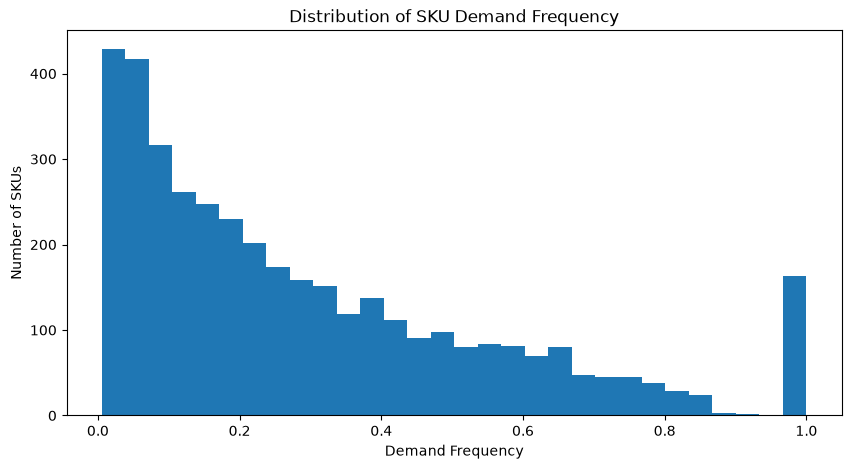

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(sku_demand_profile["demand_frequency"], bins=30)

plt.xlabel("Demand Frequency")
plt.ylabel("Number of SKUs")
plt.title("Distribution of SKU Demand Frequency")

plt.show()

**Demand-frequency distribution is strongly right-skewed.** Most SKUs have relatively low demand frequency, while the number of SKUs declines as demand frequency increases. A distinct group of SKUs has frequency near 1.0, representing products with demand recorded on essentially every day of their observed period.

**Modeling implication:** StockSense contains heterogeneous demand regimes, ranging from highly intermittent products to highly regular products. A single forecasting strategy may not be equally appropriate across all SKUs; demand segmentation should be evaluated before finalizing the forecasting architecture.

In [75]:
sku_demand_stats = (
    demand_daily.groupby("StockCode")["Demand"]
    .agg(
        mean_daily_demand="mean",
        median_daily_demand="median",
        std_daily_demand="std",
        max_daily_demand="max",
    )
    .reset_index()
)

sku_demand_stats.describe()

,mean_daily_demand,median_daily_demand,std_daily_demand,max_daily_demand
count,3936.000000,3936.000000,3778.000000,3936.000000
mean,26.249580,22.388974,15.801840,191.090447
std,1291.137998,1291.162609,72.544821,1786.976263
min,0.006803,0.000000,0.000000,1.000000
25%,0.384236,0.000000,1.594176,12.000000
50%,1.665327,0.000000,5.881050,48.000000
75%,5.305994,0.000000,17.171809,156.000000
max,80995.000000,80995.000000,4109.868865,80995.000000


**Per-SKU demand statistics:** Demand volume varies dramatically across products. The distribution of SKU-level mean daily demand is highly skewed (mean 26.25, median 1.67, maximum 80,995). The median of SKU-level median daily demand is 0, further demonstrating the prevalence of zero-demand days and intermittent demand. Extreme observations substantially affect averages, so StockSense should use robust demand statistics and carefully handle extreme demand when developing forecasting and inventory-risk features.